In [1]:
# Level 3: Specialized Insights
## Task 1: Predictive Modeling (Random Forest Classification)


--- Decision Tree Results ---
Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

--- Tuned Random Forest Results ---
Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



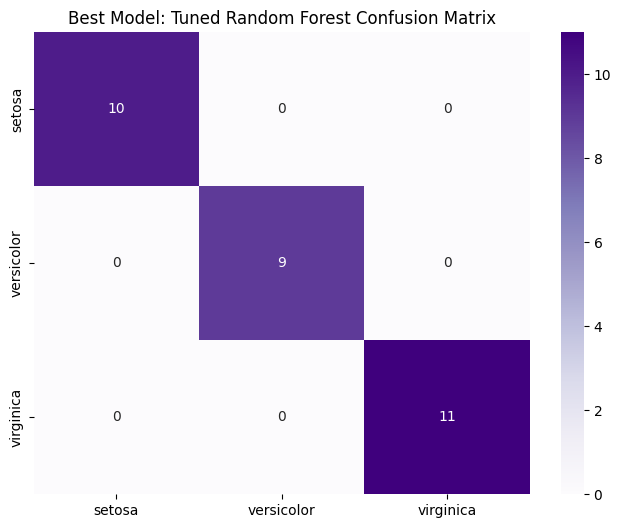

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load and Split Data
df_iris = pd.read_csv('/content/1) iris.csv')
X = df_iris.drop('species', axis=1)
y = df_iris['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Hyperparameter Tuning using Grid Search (for Random Forest)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

# 3. Train a Baseline Decision Tree for Comparison
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 4. Evaluate Both Models
models = {'Decision Tree': dt_model, 'Tuned Random Forest': best_rf}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"--- {name} Results ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))

# 5. Visualize the Best Model's Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, best_rf.predict(X_test)), annot=True, cmap='Purples',
            xticklabels=best_rf.classes_, yticklabels=best_rf.classes_)
plt.title('Best Model: Tuned Random Forest Confusion Matrix')
plt.show()
